In [1]:
!pip install datasets
!pip install -U datasets
!pip install tiktoken
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 9.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 31.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 130.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 143.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [datasets]8/9 [datasets]ce-hub]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.5/801.5 kB 110.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tiktoken]


In [2]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [3]:
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

encoder = tiktoken.get_encoding("gpt2")

def process(example):
  ids = encoder.encode_ordinary(example["text"])
  output = {'ids': ids, 'len': len(ids)}
  return output


if not os.path.exists("train.bin"):
  tokenized = ds.map(
      process,
      remove_columns = ["text"],
      desc = "tokenizing the splits",
      num_proc = 8,
  )

  for split,dset in tokenized.items():
    arr_len = np.sum(dset['len'], dtype = np.uint64)
    filename = f'{split}.bin'
    dtype = np.uint16
    arr = np.memmap(filename, dtype = dtype, mode = "w+", shape = (arr_len,))
    total_batches = 1024

    idx = 0
    for batch_idx in tqdm(range(total_batches), desc = f'writing {filename}'):
      batch = dset.shard(num_shards = total_batches, index = batch_idx, contiguous = True).with_format('numpy')
      arr_batch = np.concatenate(batch['ids'])
      arr[idx:idx+len(arr_batch)] = arr_batch
      idx += len(arr_batch)
    arr.flush()

In [4]:
import torch

def compute_rope_params(head_dim, theta_base = 10_000, context_length = 4096,dtype = torch.float32):
  assert head_dim%2==0, "Embedding dimension must be even"

  inv_freq = 1.0 / (theta_base ** (torch.arange(0,head_dim,2,dtype = dtype)[: (head_dim//2)].float()/head_dim))

  positions = torch.arange(context_length,dtype = dtype)
  angles = positions[:,None]  * inv_freq[None, :]

  angles = torch.cat([angles,angles],dim=1)

  cos = torch.cos(angles)
  sin = torch.sin(angles)
  return cos,sin

def apply_rope(x,cos,sin):
  batch_size, num_heads, seq_length ,  head_dim = x.shape
  assert head_dim%2==0 , "Head Dimension must be even"

  x1 = x[..., : head_dim//2]
  x2 = x[..., head_dim//2:]

  cos = cos[:seq_length,:].unsqueeze(0).unsqueeze(0)
  sin = sin[:seq_length,:].unsqueeze(0).unsqueeze(0)

  rotated = torch.cat((-x2,x1),dim=-1)
  x_rotated = (x*cos) + (rotated*sin)

  return x_rotated.to(dtype = x.dtype)


In [5]:
import torch
def get_batch(split):
  if split=="train":
    data = np.memmap('train.bin',dtype=np.uint16,mode='r')
  else:
    data = np.memmap('validation.bin',dtype=np.uint16,mode = 'r')
  ix = torch.randint(0, len(data)-block_size, (batch_size,))
  x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64))for i in ix])
  y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
  if device_type =="cuda":
    x,y = x.pin_memory().to(device,non_blocking = True) , y.pin_memory().to(device,non_blocking = True)
  else:
    x,y = x.to(device), y.to(device)
  return x,y

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class RMSNorm(nn.Module):
  def __init__(self,emb_dim,eps=1e-6,bias = False):
    super().__init__()
    self.eps = eps
    self.scale = nn.Parameter(torch.zeros(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim)) if bias else None

  def forward(self,x):
    input_dtype = x.dtype
    x_f = x.float()
    var = x_f.pow(2).mean(dim=-1,keepdim = True)
    x_norm = x_f * torch.rsqrt(var + self.eps)
    out = x_norm * (1.0 + self.scale.float())

    if self.shift is not None:
      out = out + self.shift.float()

    return out.to(input_dtype)

class GroupedQueryAttention(nn.Module):
  def __init__(
      self,d_in, num_heads, num_kv_groups, head_dim = None,qk_norm = False,
      query_pre_attn_scalar = None, dtype =None,
  ):
    super().__init__()
    assert num_heads % num_kv_groups == 0 , "num_heads must be divisible by num_kv_groups"

    self.num_heads = num_heads
    self.num_kv_groups = num_kv_groups
    self.group_size = num_heads // num_kv_groups

    if head_dim is None:
      assert d_in % num_heads == 0 , "d_in must be divisible by num_heads"
      head_dim = d_in //num_heads

    self.head_dim = head_dim
    self.d_out = num_heads * head_dim

    self.w_query = nn.Linear(d_in,self.d_out , bias = False,dtype= dtype)
    self.w_key = nn.Linear(d_in,num_kv_groups * head_dim , bias = False,dtype= dtype)
    self.w_value = nn.Linear(d_in,num_kv_groups * head_dim , bias = False,dtype= dtype)

    self.out_proj = nn.Linear(self.d_out , d_in , bias = False, dtype= dtype)

    if qk_norm:
      self.q_norm = RMSNorm(head_dim , eps = 1e-6)
      self.k_norm = RMSNorm(head_dim , eps = 1e-6)
    else:
      self.q_norm = self.k_norm = None

    if query_pre_attn_scalar is not None:
      self.scaling = (query_pre_attn_scalar) ** -0.5
    else:
      self.scaling = (head_dim) ** -0.5

  def forward(self,x, mask,cos,sin):
    b , num_tokens, _  = x.shape

    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)


    queries = queries.view(b, num_tokens , self.num_heads,self.head_dim).transpose(1,2)
    keys = keys.view(b,num_tokens, self.num_kv_groups,self.head_dim).transpose(1,2)
    values = values.view(b,num_tokens , self.num_kv_groups,self.head_dim).transpose(1,2)

    if self.q_norm:
      queries = self.q_norm(queries)
    if self.k_norm:
      keys = self.k_norm(keys)

    queries = apply_rope(queries,cos,sin)
    keys = apply_rope(keys,cos,sin)

    keys = keys.repeat_interleave(self.group_size,dim = 1)
    values = values.repeat_interleave(self.group_size, dim =1)

    queries = queries * self.scaling

    attn_scores = queries @ keys.transpose(2,3)
    attn_scores = attn_scores.masked_fill(mask,-torch.inf)
    attn_weights = torch.softmax(attn_scores,dim=-1)

    context = (attn_weights @ values).transpose(1,2).reshape(b,num_tokens,self.d_out)
    return self.out_proj(context)

class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.fc1 = nn.Linear(cfg["emb_dim"],cfg["hidden_dim"],dtype = cfg["dtype"],bias = False)
    self.fc2 = nn.Linear(cfg["emb_dim"],cfg["hidden_dim"],dtype = cfg["dtype"],bias = False)
    self.fc3 = nn.Linear(cfg["hidden_dim"],cfg["emb_dim"],dtype = cfg["dtype"],bias = False)

  def forward(self,x):
    x_fc1 = self.fc1(x)
    x_fc2 = self.fc2(x)
    x = nn.functional.gelu(x_fc1,approximate = "tanh") * x_fc2
    return self.fc3(x)

class TransformerBlock(nn.Module):
  def __init__(self,cfg:dict,attn_type:str):
    super().__init__()
    self.attn_type = attn_type
    self.attn = GroupedQueryAttention(
        d_in = cfg["emb_dim"],
        num_heads = cfg["n_heads"],
        num_kv_groups = cfg["n_kv_groups"],
        head_dim = cfg["head_dim"],
        qk_norm = cfg["qk_norm"],
        query_pre_attn_scalar = cfg["query_pre_attn_scalar"],
        dtype = cfg["dtype"],
    )

    self.ff = FeedForward(cfg)
    self.input_layernorm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.post_attention_layernorm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.pre_feedforward_layernorm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.post_feedforward_layernorm = RMSNorm(cfg["emb_dim"] , eps = 1e-6)

  def forward(self,x,mask_global,mask_local,cos_global,sin_global,cos_local,sin_local):
    shortcut = x
    x = self.input_layernorm(x)

    if self.attn_type =="sliding_attention":
      attn_mask = mask_local
      cos = cos_local
      sin = sin_local
    else:
      attn_mask = mask_global
      cos = cos_global
      sin = sin_global

    x_attn = self.attn(x,attn_mask,cos,sin)
    x_attn = self.post_attention_layernorm(x_attn)
    x = shortcut + x_attn

    shortcut = x
    x_ffn = self.pre_feedforward_layernorm(x)
    x_ffn = self.ff(x_ffn)
    x_ffn = self.post_feedforward_layernorm(x_ffn)
    x = shortcut + x_ffn
    return x

class Gemma3Model(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    assert cfg["layer_types"] is not None and len(cfg["layer_types"]) == cfg["n_layers"]

    self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"],dtype = cfg["dtype"])

    self.blocks = nn.ModuleList([
        TransformerBlock(cfg,attn_type) for attn_type in cfg["layer_types"]
    ])


    self.final_norm = RMSNorm(cfg["emb_dim"],eps = 1e-6)
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"],bias = False, dtype = cfg["dtype"])
    self.cfg = cfg

    cos_local , sin_local = compute_rope_params(
        head_dim = cfg["head_dim"],
        theta_base = cfg["rope_local_base"],
        context_length = cfg["context_length"],
        dtype = torch.float32,
    )

    cos_global , sin_global = compute_rope_params(
        head_dim = cfg["head_dim"],
        theta_base = cfg["rope_global_base"],
        context_length = cfg["context_length"],
        dtype = torch.float32,
    )
    self.register_buffer("cos_local", cos_local , persistent = False)
    self.register_buffer("sin_local", sin_local , persistent = False)
    self.register_buffer("cos_global", cos_global , persistent = False)
    self.register_buffer("sin_global", sin_global , persistent = False)
  
  def _create_masks(self,seq_len, device):
    ones = torch.ones((seq_len,seq_len), dtype=torch.bool, device=device)
    mask_global = torch.triu(ones, diagonal=1)
    mask_local = torch.triu(ones, diagonal=1) | torch.tril(ones, diagonal=-self.cfg["sliding_window"])  
    return mask_global, mask_local

    
  def forward(self,input_ids,targets = None):
    b,seq_len  = input_ids.shape
    x = self.tok_emb(input_ids) * (self.cfg["emb_dim"]**0.5)
    mask_global , mask_local = self._create_masks(seq_len,x.device)

    for block in self.blocks:
      x = block(
          x,
          mask_global = mask_global,
          mask_local= mask_local,
          cos_global = self.cos_global,
          sin_global = self.sin_global,
          cos_local = self.cos_local,
          sin_local = self.sin_local,
      )
    x = self.final_norm(x)
    logits = self.out_head(x.to(self.cfg["dtype"]))
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.reshape(-1,logits.size(-1)),targets.reshape(-1))
    return logits,loss


  @torch.no_grad()
  def generate(self,idx,max_new_tokens,temperature = 1.0,top_k = None):
    for _ in range(max_new_tokens):
      ctx_len = self.cfg["context_length"]
      idx_cond = idx if idx.size(1) <= ctx_len else idx[:,-ctx_len:]
      logits , _ = self(idx_cond)
      logits = logits[:,-1,:]/ temperature
      if top_k is not None:
        v , _ = torch.topk(logits, min(top_k,logits.size(-1)))
        logits[logits< v[:,[-1]]] = float('-inf')
      probs = F.softmax(logits,dim=-1)
      idx_next = torch.multinomial(probs,num_samples = 1)
      idx  = torch.cat((idx,idx_next),dim=1)
    return idx




In [7]:
GEMMA3_CONFIG_270M= {
    "vocab_size": 50257,
    "context_length": 32768,
    "emb_dim": 640,
    "n_heads": 4,
    "n_layers": 18,
    "hidden_dim": 2048,
    "head_dim": 256,
    "qk_norm": True,
    "n_kv_groups": 1,
    "rope_local_base": 10000.0,
    "rope_global_base": 1000000.0,
    "sliding_window": 4096,
    "layer_types": [
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "full_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "sliding_attention",
        "full_attention",
        "sliding_attention",
        "sliding_attention",
    ],
    "dtype": torch.bfloat16,
    "query_pre_attn_scalar": 256,
}

torch.manual_seed(123)
model = Gemma3Model(GEMMA3_CONFIG_270M)

In [8]:
def estimate_loss(model):
  out = {}
  model.eval()
  with torch.inference_mode():
    for split in ['train','val']:
      losses = torch.zeros(eval_iters)
      for k in range(eval_iters):
        x,y = get_batch(split)
        with ctx:
          logits, loss = model(x,y)
        losses[k] = loss.item()
      out[split] = losses.mean()
  model.train()
  return out

In [ ]:
import torch
from contextlib import nullcontext
learning_rate = 1e-4
max_iters = 150000
warmup_steps = 1000
min_lr = 5e-4
eval_iters = 500
batch_size = 32
block_size = 128

gradient_accumulation_steps = 32

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu'

dtype = "bfloat16" if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else "float16"
ptdtype = {'float32': torch.float32,'bfloat16': torch.bfloat16,'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type =="cpu" else torch.amp.autocast(device_type = device_type,dtype = ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

In [10]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

optimizer = torch.optim.AdamW(model.parameters() , lr = learning_rate, betas = (0.9,0.95),weight_decay = 0.1, eps = 1e-9)

scheduler_warmup = LinearLR(optimizer,total_iters = warmup_steps)
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps,eta_min = min_lr)
scheduler = SequentialLR(optimizer, schedulers = [scheduler_warmup,scheduler_decay],milestones = [warmup_steps])

scaler = torch.amp.GradScaler('cuda', enabled=(dtype == 'float16'))

In [11]:
import os
import torch
from tqdm import tqdm

best_model_params_path = "best_model_params.pt"
interrupt_checkpoint_path = "resume_checkpoint.pt"

start_epoch = 0
best_val_loss = float('inf')
train_loss_list, validation_loss_list = [], []

model = model.to(device)

if os.path.exists(interrupt_checkpoint_path):
    print(f"Found interrupt checkpoint. Resuming training...")
    checkpoint = torch.load(interrupt_checkpoint_path)
    
    # Restore model, optimizer, scaler, and scheduler states
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    train_loss_list = checkpoint['train_loss_list']
    validation_loss_list = checkpoint['validation_loss_list']
    print(f"Successfully resumed. Starting from iteration {start_epoch}.")
else:
    print("No resume checkpoint found. Starting from scratch.")


try:
    for epoch in tqdm(range(start_epoch, max_iters), initial=start_epoch, total=max_iters):
        
        if epoch % eval_iters == 0 and epoch != 0:
            model.eval() 
            losses = estimate_loss(model)
            model.train() 
            
            print(f"Epoch {epoch}: train_loss {losses['train']:.4f} , val_loss {losses['val']:.4f}")
            print(f"The Current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
            
            train_loss_list.append(losses['train'].item())
            validation_loss_list.append(losses['val'].item())

            if losses['val'] < best_val_loss:
                best_val_loss = losses['val']
                torch.save(model.state_dict(), best_model_params_path)

        x, y = get_batch('train')
        x, y = x.to(device), y.to(device)

        with ctx:
            logits, loss = model(x, y)
            loss = loss / gradient_accumulation_steps
            
        scaler.scale(loss).backward()

        if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
            
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            scheduler.step()

except KeyboardInterrupt:
    print(f"\n[!] Training interrupted by user at iteration {epoch}.")
    print("Saving full state to resume later...")

    
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'train_loss_list': train_loss_list,
        'validation_loss_list': validation_loss_list
    }, interrupt_checkpoint_path)
    
    print("State saved! You can now run inference.")

Found interrupt checkpoint. Resuming training...


Successfully resumed. Starting from iteration 74024.


 50%|████▉     | 74501/150000 [01:05<109:14:10,  5.21s/it]

Epoch 74500: train_loss 2.7253 , val_loss 2.7313
The Current learning rate: 0.00010


 50%|████▉     | 74999/150000 [01:57<1:29:12, 14.01it/s]  

...

 99%|█████████▉| 149001/150000 [2:45:04<1:13:09,  4.39s/it]

Epoch 149000: train_loss 2.4587 , val_loss 2.4671
The Current learning rate: 0.00010


100%|█████████▉| 149499/150000 [2:45:51<00:36, 13.61it/s]  

Epoch 149500: train_loss 2.4631 , val_loss 2.4587
The Current learning rate: 0.00010


100%|██████████| 150000/150000 [2:46:46<00:00,  7.59it/s]


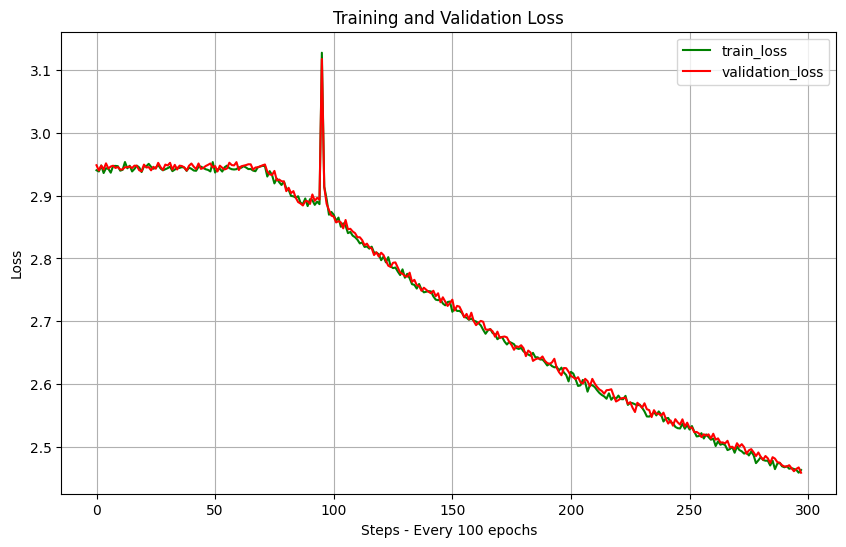

In [ ]:
!pip install matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 
plt.plot(train_loss_list, 'g', label='train_loss')
plt.plot(validation_loss_list, 'r', label='validation_loss')

plt.title("Training and Validation Loss")
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True) 
plt.show()

In [13]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Gemma3Model(GEMMA3_CONFIG_270M)
model = model.to(device) 


best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device), weights_only=True)) 
model.eval() 


sentence = "Once upon a time"
context = torch.tensor(encoder.encode_ordinary(sentence)).unsqueeze(dim=0).to(device)

with torch.no_grad(): 
    y = model.generate(context, 500)

print(encoder.decode(y.squeeze().tolist()))

Once upon a time there was a nice little luck. He was very proud of himself all the other unicorn. He had a big fight and made something soft. One of his friends came to him and tried to have some money. The other boy opened the shells and sent hard at all the 414. He knew he could make a swim, so he grabbed his challenge. 

Then, a little girl was scared and wished he had listened to the 3 year old one. She asked him how he was looking for it and she told him he was tired. The little boy shook and said he was sorry. 

The little boy smiled and practiced in the playground. After a few weeks, the mommy and daughter felt better. The little boy warned yield and asked John and the little boy wasacked. 

The little boy was so excited and he thought to himself for it. He looked up at the little boy, but he was not sure to make her feel better. So he gave He carried up the doll home and left his house. 

At the end of his humblealks something very special way. It was a mystery!

The little bo

In [17]:
sentence = "Once upon a time there was a girl"
context = torch.tensor(encoder.encode_ordinary(sentence)).unsqueeze(dim=0).to(device)

with torch.no_grad(): 
    y = model.generate(context, 500)

print(encoder.decode(y.squeeze().tolist()))

Once upon a time there was a girl calledOnce upon a time, there was a very polite used to travel to deliver by a boy. Everyone wanted to know the best treasure is nice to him. 

One day, he went over to the Chloe and he found a small car that was Kag. He asked Bobby what it was, and her mom explained to him that there was a fast car, but this made him feel the coming down. 

The next week, the car saw running to a tall shell's house. The girl struggled bought the Cream and they began to spell together. Then, one day a new little girl called Bella took the car to his car and solved. 

At home, Grandma lived in a storm show. She was so excited and ran back owner told her pet the girl ever seen. They opened the door and saw lots of fun sounds which was driving with the buckle. 

The girl nodded and they decided to go on a painting. When the opera was close to the bottle, the girl was growing back to the beach. The mom was so happy that the naughty little girl thought it was a great kingdo

In [18]:
sentence = "Once upon a time there was a pumpkin"
context = torch.tensor(encoder.encode_ordinary(sentence)).unsqueeze(dim=0).to(device)

with torch.no_grad(): 
    y = model.generate(context, 500)

print(encoder.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. It was sunny full of fun world. All of them had lots of leaves the tiger was the same. Every day he would balance one morning, exploring that soon found the forest and replaced his strength and permission when were done, the group was strong and could choke cleaning its eyes! But the next time the tiger made a mistake. Everyone moved faster and faster, after they noticed that the angels returned to. In the end, they were impressed and everyone never knew now.Once there was a little girl named Sarah. Sarah told her brother she was trying to get in her home. Sarah asked her mum told her to follow her to the park.

First, Sarah found one! She replied in a big bush from many things to hear the garbage mine. Everything was silly and not enough to get into the bush.

Sarah was frustrated. â€œHello!â€ she said with a smile enough of their own. She stopped on thetime together and feeling the alligator promised himself.

The night, Jim decided they could do

In [14]:
!pip install huggingface_hub

In [20]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import login, HfApi

api = HfApi()
repo_id = "Parthiban007/Gemma_3_270M"

files_to_push = [
    "best_model_params.pt", 
    "resume_checkpoint.pt", 
    "train.bin", 
    "validation.bin",
    "gemma_3.ipynb"
]


# 4. Upload loop
for file_name in files_to_push:
    print(f"Uploading {file_name}...")
    try:
        api.upload_file(
            path_or_fileobj=file_name,
            path_in_repo=file_name,
            repo_id=repo_id,
        )
        
        print(f"✅ Successfully uploaded {file_name}")
    except Exception as e:
        print(f"❌ Failed to upload {file_name}: {e}")

print(f"\n🚀 All done! View your model at: https://huggingface.co/{repo_id}")

Uploading best_model_params.pt...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Successfully uploaded best_model_params.pt
Uploading resume_checkpoint.pt...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Successfully uploaded resume_checkpoint.pt
Uploading train.bin...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            